Peroforming Token Classification task (NER) on Medical Dataset

In [ ]:
!pip install -U bitsandbytes
!pip install seqeval

In [ ]:
from transformers import AutoModelForTokenClassification, DataCollatorForTokenClassification,BitsAndBytesConfig
from peft import LoraConfig, get_peft_model # Make sure you import these
import torch

In [ ]:
from transformers.trainer import Trainer
from torch.nn import CrossEntropyLoss
import torch

In [ ]:
!pip install -U bitsandbytes

In [ ]:
from bitsandbytes.optim import PagedAdamW8bit

In [ ]:
import json
from collections import defaultdict
import spacy
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForTokenClassification, TrainingArguments, Trainer
import numpy as np


In [ ]:
# --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
#  STEP 1: DEFINE MAPPING and PRECEDENCE HIERARCHY
# --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---

# This dictionary is the rulebook that converts raw UMLS Type IDs
# into your desired human-readable categories.
TYPE_MAPPING = {
    # DISEASE
    "T047": "DISEASE", "T191": "DISEASE", "T046": "DISEASE",
    "T020": "DISEASE", "T019": "DISEASE", "T048": "DISEASE",
    # SYMPTOM
    "T184": "SYMPTOM",
    # GENE_PROTEIN
    "T028": "GENE_PROTEIN", "T116": "GENE_PROTEIN", "T085": "GENE_PROTEIN",
    "T086": "GENE_PROTEIN", "T087": "GENE_PROTEIN",
    # DRUG
    "T121": "DRUG", "T127": "DRUG", "T122": "DRUG", "T131": "DRUG",
    # CHEMICAL
    "T109": "CHEMICAL", "T120": "CHEMICAL", "T103": "CHEMICAL",
    "T104": "CHEMICAL", "T197": "CHEMICAL",
    # ANATOMY
    "T023": "ANATOMY", "T022": "ANATOMY", "T024": "ANATOMY",
    "T030": "ANATOMY", "T029": "ANATOMY",
    # CELL_LINE
    "T025": "CELL_LINE", "T026": "CELL_LINE",
    # DIAGNOSTIC_TEST
    "T060": "DIAGNOSTIC_TEST", "T059": "DIAGNOSTIC_TEST", "T034": "DIAGNOSTIC_TEST",
    # TREATMENT
    "T061": "TREATMENT",
    # QUANTITY
    "T081": "QUANTITY", "T080": "QUANTITY", "T082": "QUANTITY"
}

# This list defines the tie-breaking rule (highest priority first).
PRECEDENCE_HIERARCHY = [
    "GENE_PROTEIN", "DRUG", "DISEASE", "SYMPTOM", "ANATOMY",
    "CELL_LINE", "DIAGNOSTIC_TEST", "TREATMENT", "CHEMICAL", "QUANTITY", "MISC"
]

In [ ]:
def normalize_text(text):
    return text.lower().strip()

In [ ]:

def parse_and_map_pubtator(file_path):
    """Parses the PubTator file and applies the initial type mapping."""
    documents = []
    with open(file_path, 'r', encoding='utf-8') as f:
        blocks = f.read().strip().split('\n\n')

        for block in blocks:
            lines = block.strip().split('\n')
            if len(lines) < 2: continue

            title_line, abstract_line = lines[0], lines[1]
            pmid, _, title = title_line.partition('|t|')
            _, _, abstract = abstract_line.partition('|a|')
            full_text = title + " " + abstract

            entities = []
            for line in lines[2:]:
                parts = line.split('\t')
                if len(parts) == 6:
                    try:
                        start, end = int(parts[1]), int(parts[2])
                        entity_text, original_types, concept_id,  = parts[3], parts[4], parts[5]

                        # Use the first type for mapping if multiple are present
                        first_type = original_types.split(',')[0]

                        # Apply mapping: If type not in map, default to 'MISC'
                        mapped_type = TYPE_MAPPING.get(first_type, "MISC")

                        entities.append({
                            "start": start, "end": end,
                            "text": entity_text, "type": mapped_type,
                            "concept_id": concept_id
                        })
                    except ValueError:
                        continue

            documents.append({"pmid": pmid, "text": full_text, "entities": entities})
    print("✅ Step 1: Parsing  initial mapping and concept id extraction complete.")
    return documents


In [ ]:

def resolve_ambiguity(documents, precedence_list):
    """Resolves entity type ambiguity using the precedence hierarchy."""
    precedence_map = {name: i for i, name in enumerate(precedence_list)}

    text_to_labels = defaultdict(set)
    for doc in documents:
        for entity in doc['entities']:
            text_to_labels[entity['text']].add(entity['type'])

    resolution_map = {}
    for text, labels in text_to_labels.items():
        if len(labels) > 1:
            best_label = min(labels, key=lambda label: precedence_map.get(label, 999))
            resolution_map[text] = best_label

    cleaned_documents_temp1 = []
    for doc in documents:
        new_entities = []
        added_entities_in_doc = set()
        for entity in doc['entities']:
            entity_key = (entity['start'], entity['end'], entity['text'])
            if entity['text'] in resolution_map:
                resolved_type = resolution_map[entity['text']]
                if entity['type'] == resolved_type and entity_key not in added_entities_in_doc:
                    new_entity = entity.copy()
                    new_entity['type'] = resolved_type
                    new_entities.append(new_entity)
                    added_entities_in_doc.add(entity_key)
            elif entity_key not in added_entities_in_doc:
                new_entities.append(entity)
                added_entities_in_doc.add(entity_key)

        doc['entities'] = new_entities
        cleaned_documents_temp1.append(doc)

    print(f"✅ Step 2: Ambiguity resolution complete. {len(resolution_map)} conflicts resolved.")
    return cleaned_documents_temp1


In [ ]:
def enforce_concept_id_consistency(documents):
    """Ensures that all entities with the same Concept ID have the same final entity type."""
    concept_id_to_types = defaultdict(list)
    for doc in documents:
        for entity in doc['entities']:
          if entity['concept_id'] != "-1":
            concept_id_to_types[entity['concept_id']].append(entity['type'])

    concept_id_resolution = {}
    for concept_id, types in concept_id_to_types.items():
        if len(set(types)) > 1:
            # Find the most common type for this concept ID
            majority_type = Counter(types).most_common(1)[0][0]
            concept_id_resolution[concept_id] = majority_type

    for doc in documents:
        for entity in doc['entities']:
            if entity['concept_id'] in concept_id_resolution:
                entity['type'] = concept_id_resolution[entity['concept_id']]

    print(f"✅ Step 3: Concept ID consistency enforced. {len(concept_id_resolution)} conflicts resolved.")
    return documents

In [ ]:
def resolve_overlapping_entities(documents):
    """Resolves overlapping entities using the 'longest entity wins' rule."""
    for doc in documents:
        entities = sorted(doc['entities'], key=lambda x: x['start'])
        if not entities: continue

        non_overlapping_entities = [entities[0]]
        for i in range(1, len(entities)):
            current_entity = entities[i]
            last_entity = non_overlapping_entities[-1]

            # Check for overlap
            if current_entity['start'] < last_entity['end']:
                # Overlap detected, apply the 'longest entity wins' rule
                if (current_entity['end'] - current_entity['start']) > (last_entity['end'] - last_entity['start']):
                    # Current entity is longer, so it replaces the last one
                    non_overlapping_entities[-1] = current_entity
                # Otherwise, the current (shorter) entity is simply skipped
            else:
                # No overlap
                non_overlapping_entities.append(current_entity)
        doc['entities'] = non_overlapping_entities
    print("✅ Step 4: Overlapping entities resolved.")
    return documents

In [ ]:

def enforce_consistency_and_filter_noise(documents, nlp_model):
    """
    Refines entity boundaries using linguistic rules and filters out noisy labels.
    """
    consistent_docs = []
    POS_TO_TRIM = {"ADP", "DET", "CCONJ"} # Prepositions, Articles, Conjunctions
    STOP_LIST_ENTITIES = {"the", "a", "an", "of", "in", "is", "was", "and", "or", "to", "for", "study", "results", "analysis"}

    for doc in documents:
        full_text_doc = nlp_model(doc['text'])
        new_entities = []
        for entity in doc['entities']:
            original_label = entity['type']
            try:
                span = full_text_doc.char_span(entity['start'], entity['end'])
                if span is not None:
                    # --- Rule 1: Refine Boundaries ---
                    while len(span) > 1 and span[0].pos_ in POS_TO_TRIM:
                        span = span[1:]

                    # --- Rule 2: Filter by Length ---
                    if len(span.text) <= 2:
                        continue # Skip this entity if it's too short

                    # --- Rule 3: Filter by Stop List ---
                    if span.text.lower() in STOP_LIST_ENTITIES:
                        continue # Skip this entity if it's a common stop word

                    new_entities.append({
                        "text": span.text,
                        "type": original_label,
                        "start": span.start_char,
                        "end": span.end_char
                    })
            except Exception:
                continue
        doc['entities'] = new_entities
        consistent_docs.append(doc)
    print("✅ Step 5: Boundary consistency and noise filtering complete.")
    return consistent_docs

In [ ]:
if __name__ == "__main__":
    input_file = '/content/corpus_pubtator1.txt'
    output_file = 'cleaned_dataset_final.json'

    # --- Run the full, enhanced preprocessing pipeline ---
    docs = parse_and_map_pubtator(input_file)
    docs = resolve_ambiguity(docs, PRECEDENCE_HIERARCHY)
    docs = enforce_concept_id_consistency(docs)
    final_docs = resolve_overlapping_entities(docs)

    # --- This is the corrected section ---
    # 1. Load the spaCy model required by the next function
    print("Loading spaCy model for final cleaning steps...")
    nlp = spacy.load("en_core_web_sm")

    # 2. Call the function with both required arguments
    'final_docs = enforce_consistency_and_filter_noise(docs, nlp)'

    # 3. Save the final, fully cleaned dataset
    with open(output_file, 'w', encoding='utf-8') as f:
        json.dump(final_docs, f, indent=2)

    print(f"\n🎉 Success! Enhanced, clean dataset saved to '{output_file}'")

✅ Step 1: Parsing  initial mapping and concept id extraction complete.
✅ Step 2: Ambiguity resolution complete. 4569 conflicts resolved.
✅ Step 3: Concept ID consistency enforced. 0 conflicts resolved.
✅ Step 4: Overlapping entities resolved.
Loading spaCy model for final cleaning steps...

🎉 Success! Enhanced, clean dataset saved to 'cleaned_dataset_final.json'


## Step 1: Data Exploration and Class Distribution Analysis
Before training, you need to understand the statistical properties of your final dataset. The main goal is to quantify the class imbalance, which will inform how you train your model.

Action: Write a simple script to load cleaned_dataset.json and count the frequency of your final 11 entity categories.

In [ ]:
import json
from collections import Counter

with open('/content/cleaned_dataset_final.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

entity_counts = Counter()
for doc in data:
    for entity in doc['entities']:
        entity_counts[entity['type']] += 1

print("--- Final Entity Class Distribution ---")
for entity_type, count in entity_counts.most_common():
    print(f"{entity_type}: {count} examples")

--- Final Entity Class Distribution ---
MISC: 131354 examples
QUANTITY: 46478 examples
DISEASE: 22772 examples
GENE_PROTEIN: 20483 examples
CHEMICAL: 10517 examples
TREATMENT: 10401 examples
DIAGNOSTIC_TEST: 9447 examples
ANATOMY: 8545 examples
CELL_LINE: 6668 examples
DRUG: 5354 examples
SYMPTOM: 1517 examples


## Step 2: Perform Cost Sensitive Learning

Divide Examples from Majority class / Examples from Minority Class


## Step 3: Train Test And Validation

In [ ]:
import json
from collections import Counter
from sklearn.model_selection import train_test_split

with open('/content/cleaned_dataset_final.json', 'r', encoding='utf-8') as f:
    documents = json.load(f)

# Create a representative label for each document for stratification
labels = []
for doc in documents:
    if doc['entities']:
        doc_labels = [entity['type'] for entity in doc['entities']]
        labels.append(Counter(doc_labels).most_common(1)[0][0])
    else:
        labels.append('NO_ENTITY')

# First split: 80% train, 20% temp
train_docs_final, temp_docs, _, _ = train_test_split(
    documents, labels, test_size=0.2, random_state=42, stratify=labels)

# Re-stratify the temp set for the final split
temp_labels = []
for doc in temp_docs:
    if doc['entities']:
        doc_labels = [entity['type'] for entity in doc['entities']]
        temp_labels.append(Counter(doc_labels).most_common(1)[0][0])
    else:
        temp_labels.append('NO_ENTITY')

val_docs_final, test_docs_final, _, _ = train_test_split(
    temp_docs, temp_labels, test_size=0.5, random_state=42, stratify=temp_labels)

# Save the splits to new files
with open('train_dataset_final.json', 'w') as f: json.dump(train_docs_final, f)
with open('validation_dataset_final.json', 'w') as f: json.dump(val_docs_final, f)
with open('test_dataset_final.json', 'w') as f: json.dump(test_docs_final, f)

print(f"\nDataset split complete:")
print(f"Training set size: {len(train_docs_final)}")
print(f"Validation set size: {len(val_docs_final)}")
print(f"Test set size: {len(test_docs_final)}")


Dataset split complete:
Training set size: 3513
Validation set size: 439
Test set size: 440


## Step 4: Convert Data to BIO Format
This is the final transformation. NER models need the data in the BIO (Beginning, Inside, Outside) format to correctly handle multi-word entities.

Action: Convert each of your new JSON files into a format containing lists of tokens and their corresponding BIO tags.

In [ ]:

import json
import spacy

nlp = spacy.blank("en")

def convert_to_bio_format(documents):
    bio_data = []
    for doc in documents:
        spacy_doc = nlp(doc['text'])
        tokens = [token.text for token in spacy_doc]
        tags = ['O'] * len(tokens)

        for entity in doc['entities']:
            span = spacy_doc.char_span(entity['start'], entity['end'], label=entity['type'])
            if span:
                tags[span.start] = f"B-{entity['type']}"
                for i in range(span.start + 1, span.end):
                    tags[i] = f"I-{entity['type']}"

        bio_data.append({"tokens": tokens, "ner_tags": tags})
    return bio_data

# Convert all three splits
train_bio = convert_to_bio_format(train_docs_final)
val_bio = convert_to_bio_format(val_docs_final)
test_bio = convert_to_bio_format(test_docs_final)

# Save the final, model-ready data
with open('train_bio_final.json', 'w') as f: json.dump(train_bio, f)
with open('validation_bio_final.json', 'w') as f: json.dump(val_bio, f)
with open('test_bio_final.json', 'w') as f: json.dump(test_bio, f)

print("\nBIO conversion complete. Data is ready for model training.")


BIO conversion complete. Data is ready for model training.


Loading Datasets

In [ ]:
from datasets import load_dataset

# 1. Define the paths to your final, BIO-formatted JSON files
data_files = {
    "train": "/content/train_bio_final.json",
    "validation": "/content/validation_bio_final.json",
    "test": "/content/test_bio_final.json"
}

# 2. Load the data from the files into a single DatasetDict object
# The 'json' argument tells the library how to read the files.
raw_datasets = load_dataset("json", data_files=data_files)

# 3. (Optional) Print the loaded object to see its structure
print("--- Datasets loaded successfully! ---")
print(raw_datasets)

# You can also inspect a single example from the training set
print("\n--- First example from the training set ---")
print(raw_datasets["train"][0])

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

--- Datasets loaded successfully! ---
DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 3513
    })
    validation: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 439
    })
    test: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 440
    })
})

--- First example from the training set ---
{'tokens': ['Presumptive', 'Spontaneous', 'Lysosomal', 'Storage', '-', 'Like', 'Disease', 'in', 'a', 'Crl', ':', 'CD1(ICR', ')', 'Mouse', 'A', 'clinically', 'unremarkable', '4.5', '-', 'mo', '-', 'old', 'female', 'Crl', ':', 'CD1(ICR', ')', 'VAF', '/', 'Elite', 'mouse', 'was', 'euthanized', 'for', 'scheduled', 'sentinel', 'processing', '.', 'Gross', 'necropsy', 'findings', 'included', 'significant', 'hepatosplenomegaly', 'and', 'visceral', 'lymphadenomegaly', ',', 'resulting', 'in', 'a', 'preliminarygross', 'diagnosis', 'of', 'lymphoma', '.', 'Histology', 'revealed', 'florid', 'accumulations', 'of', 'large', ','

Importing Libraries

Prepare the label list

In [ ]:
import json

def prepare_label_list(bio_json_file):
    """
    Reads a BIO-formatted JSON file and creates a sorted list of unique
    NER tags and the corresponding id/label mappings.

    Args:
        bio_json_file (str): Path to the BIO-formatted training data file.

    Returns:
        tuple: A tuple containing (label_list, label_to_id, id_to_label).
    """

    # Load the BIO-formatted training data
    with open(bio_json_file, 'r', encoding='utf-8') as f:
        data = json.load(f)

    # Use a set to automatically handle duplicates and find all unique tags
    unique_labels = set()
    for item in data:
        for tag in item['ner_tags']:
            unique_labels.add(tag)

    # Convert the set to a sorted list for consistent ordering
    label_list = sorted(list(unique_labels))

    # Create the required mappings for the Hugging Face model
    label_to_id = {label: i for i, label in enumerate(label_list)}
    id_to_label = {i: label for i, label in enumerate(label_list)}

    return label_list, label_to_id, id_to_label

# --- Main Execution ---
if __name__ == "__main__":
    training_file = '/content/train_bio_final.json'

    # Generate the label list and mappings
    LabelList, label2id, id2label = prepare_label_list(training_file)

    print("--- Complete List of Unique BIO Tags ---")
    print(LabelList)


    print(f"\nTotal number of unique labels: {len(LabelList)}")

    print("\n--- Mapping from Label to ID (label2id) ---")
    print(label2id)
    print("\n--- Mapping from ID TO label (id2label) ---")
    print(id2label)

--- Complete List of Unique BIO Tags ---
['B-ANATOMY', 'B-CELL_LINE', 'B-CHEMICAL', 'B-DIAGNOSTIC_TEST', 'B-DISEASE', 'B-DRUG', 'B-GENE_PROTEIN', 'B-MISC', 'B-QUANTITY', 'B-SYMPTOM', 'B-TREATMENT', 'I-ANATOMY', 'I-CELL_LINE', 'I-CHEMICAL', 'I-DIAGNOSTIC_TEST', 'I-DISEASE', 'I-DRUG', 'I-GENE_PROTEIN', 'I-MISC', 'I-QUANTITY', 'I-SYMPTOM', 'I-TREATMENT', 'O']

Total number of unique labels: 23

--- Mapping from Label to ID (label2id) ---
{'B-ANATOMY': 0, 'B-CELL_LINE': 1, 'B-CHEMICAL': 2, 'B-DIAGNOSTIC_TEST': 3, 'B-DISEASE': 4, 'B-DRUG': 5, 'B-GENE_PROTEIN': 6, 'B-MISC': 7, 'B-QUANTITY': 8, 'B-SYMPTOM': 9, 'B-TREATMENT': 10, 'I-ANATOMY': 11, 'I-CELL_LINE': 12, 'I-CHEMICAL': 13, 'I-DIAGNOSTIC_TEST': 14, 'I-DISEASE': 15, 'I-DRUG': 16, 'I-GENE_PROTEIN': 17, 'I-MISC': 18, 'I-QUANTITY': 19, 'I-SYMPTOM': 20, 'I-TREATMENT': 21, 'O': 22}

--- Mapping from ID TO label (id2label) ---
{0: 'B-ANATOMY', 1: 'B-CELL_LINE', 2: 'B-CHEMICAL', 3: 'B-DIAGNOSTIC_TEST', 4: 'B-DISEASE', 5: 'B-DRUG', 6: 'B-GENE_



Load the model and tokenizer



In [ ]:
from transformers import AutoTokenizer, AutoModelForTokenClassification, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model
import torch

In [ ]:
model_name = "dmis-lab/biobert-base-cased-v1.2"

# IMPORTANT: You need your label list from the previous data prep steps
# Example for demonstration:

tokenizer = AutoTokenizer.from_pretrained(model_name)

# Step 3b: Define QLoRA Config
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

# Step 3c: Load Quantized Model
model = AutoModelForTokenClassification.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    num_labels=len(LabelList),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

# Step 3d: Apply LoRA Adapters
peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["query", "value"], # Modules to adapt
    lora_dropout=0.05,
    bias="none",
    task_type="TOKEN_CLS" # CRITICAL: Use "TOKEN_CLS" for NER
)

# This is the final model object you will use for training
qlora_model = get_peft_model(model, peft_config)

print("--- Trainable Parameters after applying QLoRA ---")
qlora_model.print_trainable_parameters()



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Some weights of BertForTokenClassification were not initialized from the model checkpoint at dmis-lab/biobert-base-cased-v1.2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


--- Trainable Parameters after applying QLoRA ---
trainable params: 607,511 || all params: 108,344,878 || trainable%: 0.5607


In [ ]:
model_name = "dmis-lab/biobert-base-cased-v1.2"

# IMPORTANT: You need your label list from the previous data prep steps
# Example for demonstration:

tokenizer = AutoTokenizer.from_pretrained(model_name)

# Step 3b: Define QLoRA Config
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

# Step 3c: Load Quantized Model
model = AutoModelForTokenClassification.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    num_labels=len(LabelList),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

# Step 3d: Apply LoRA Adapters
peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["query", "value"], # Modules to adapt
    lora_dropout=0.05,
    bias="none",
    task_type="TOKEN_CLS" # CRITICAL: Use "TOKEN_CLS" for NER
)

# This is the final model object you will use for training
qlora_model = get_peft_model(model, peft_config)

print("--- Trainable Parameters after applying QLoRA ---")
qlora_model.print_trainable_parameters()



model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Some weights of BertForTokenClassification were not initialized from the model checkpoint at dmis-lab/biobert-base-cased-v1.2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


--- Trainable Parameters after applying QLoRA ---
trainable params: 607,511 || all params: 108,344,878 || trainable%: 0.5607


Tokenize and align label

In [ ]:
# Assume 'tokenizer', 'raw_datasets', and 'label2id' are already defined
# tokenizer = AutoTokenizer.from_pretrained(...)
# raw_datasets = load_dataset(...)
# label_list, label2id, id2label = prepare_label_list(...)

def tokenize_and_align_labels(examples):
    """
    Tokenizes text and aligns BIO labels with the new sub-word tokens.
    """
    # Tokenize the words. `is_split_into_words=True` is important.
    tokenized_inputs = tokenizer(
        examples["tokens"],
        truncation=True,
        padding=True,
        is_split_into_words=True,
        max_length=512
    )

    labels = []
    # Loop over each document in the batch
    for i, label in enumerate(examples["ner_tags"]):
        # Get the word IDs for the current document's tokens
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []

        # Loop over the word IDs to align labels
        for word_idx in word_ids:
            # Special tokens (like [CLS], [SEP]) have a word_idx of None.
            # We set their label to -100 so they are automatically ignored in the loss function.
            if word_idx is None:
                label_ids.append(-100)

            # If we're at the first token of a new word, we set its label.
            elif word_idx != previous_word_idx:
                label_ids.append(label2id[label[word_idx]])

            # If we're at a subsequent token of the same word (a sub-word),
            # we also set its label to -100 to ignore it.
            else:
                label_ids.append(-100)

            previous_word_idx = word_idx

        labels.append(label_ids)

    # Add the aligned labels to the tokenized inputs
    tokenized_inputs["labels"] = labels
    return tokenized_inputs

# --- Apply the function to all splits in your dataset ---
print("Tokenizing and aligning labels for all datasets...")
tokenized_datasets = raw_datasets.map(tokenize_and_align_labels, batched=True)

print("✅ Tokenization complete!")
print("\n--- Example of a processed entry ---")
print(tokenized_datasets["train"][0])

Tokenizing and aligning labels for all datasets...


Map:   0%|          | 0/3513 [00:00<?, ? examples/s]

Map:   0%|          | 0/439 [00:00<?, ? examples/s]

Map:   0%|          | 0/440 [00:00<?, ? examples/s]

✅ Tokenization complete!

--- Example of a processed entry ---
{'tokens': ['Presumptive', 'Spontaneous', 'Lysosomal', 'Storage', '-', 'Like', 'Disease', 'in', 'a', 'Crl', ':', 'CD1(ICR', ')', 'Mouse', 'A', 'clinically', 'unremarkable', '4.5', '-', 'mo', '-', 'old', 'female', 'Crl', ':', 'CD1(ICR', ')', 'VAF', '/', 'Elite', 'mouse', 'was', 'euthanized', 'for', 'scheduled', 'sentinel', 'processing', '.', 'Gross', 'necropsy', 'findings', 'included', 'significant', 'hepatosplenomegaly', 'and', 'visceral', 'lymphadenomegaly', ',', 'resulting', 'in', 'a', 'preliminarygross', 'diagnosis', 'of', 'lymphoma', '.', 'Histology', 'revealed', 'florid', 'accumulations', 'of', 'large', ',', "'", 'foamy', "'", 'macrophages', 'present', 'in', 'the', 'bone', 'marrow', ',', 'small', 'intestines', ',', 'and', 'viscera', 'including', 'liver', ',', 'spleen', ',', 'lymph', 'nodes', ',', 'thymus', ',', 'uterus', ',', 'and', 'ovaries', '.', 'The', 'cytoplasm', 'of', 'these', 'cells', 'was', 'abundant', ',', 'st

Prepare the Class weights for cost sensitive learning

In [ ]:
import json
from collections import Counter

with open('/content/cleaned_dataset_final.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

entity_counts = Counter()
for doc in data:
    for entity in doc['entities']:
        entity_counts[entity['type']] += 1

print("--- Final Entity Class Distribution ---")
for entity_type, count in entity_counts.most_common():
    print(f"{entity_type}: {count} examples")

--- Final Entity Class Distribution ---
MISC: 131354 examples
QUANTITY: 46478 examples
DISEASE: 22772 examples
GENE_PROTEIN: 20483 examples
CHEMICAL: 10517 examples
TREATMENT: 10401 examples
DIAGNOSTIC_TEST: 9447 examples
ANATOMY: 8545 examples
CELL_LINE: 6668 examples
DRUG: 5354 examples
SYMPTOM: 1517 examples


In [ ]:
import pandas as pd

# Calculate total number of examples (entities)
total_entities = sum(entity_counts.values())

print("\n--- Cost Sensitive Learning Weights ---")
print(f"Total entities: {total_entities}")
print("-" * 35)

# Calculate weights using the user-specified formula
# Weight = Total number of examples / Number of examples for that class

print(f"Formula: Weight = Total entities ({total_entities}) / Number of examples for a specific class")
print("-" * 35)

weights_data = []
weights = {} # Initialize the weights dictionary
for entity_type, count in entity_counts.most_common():
    # Avoid division by zero if a class has no examples (though unlikely with most_common)
    if count > 0:
        weight = total_entities / count
        weights[entity_type] = weight
        weights_data.append({
            "Entity Type": entity_type,
            "Example Count": count,
            "Calculation": f"{total_entities} / {count}",
            "Weight": round(weight, 2)
        })
    else:
        weights[entity_type] = 0.00 # Assign 0 weight to classes with no examples
        weights_data.append({
            "Entity Type": entity_type,
            "Example Count": count,
            "Calculation": "N/A",
            "Weight": 0.00
        })

# Create a pandas DataFrame
weights_df = pd.DataFrame(weights_data)

# Display the DataFrame
display(weights_df)

print("-" * 35)

# You can now use the 'weights' dictionary in your model training
# Example: print(weights)


--- Cost Sensitive Learning Weights ---
Total entities: 273536
-----------------------------------
Formula: Weight = Total entities (273536) / Number of examples for a specific class
-----------------------------------


,Entity Type,Example Count,Calculation,Weight
0,MISC,131354,273536 / 131354,2.08
1,QUANTITY,46478,273536 / 46478,5.89
2,DISEASE,22772,273536 / 22772,12.01
3,GENE_PROTEIN,20483,273536 / 20483,13.35
4,CHEMICAL,10517,273536 / 10517,26.01
5,TREATMENT,10401,273536 / 10401,26.30
6,DIAGNOSTIC_TEST,9447,273536 / 9447,28.95
7,ANATOMY,8545,273536 / 8545,32.01
8,CELL_LINE,6668,273536 / 6668,41.02
9,DRUG,5354,273536 / 5354,51.09


-----------------------------------


In [ ]:
import torch

In [ ]:
print("\n--- Preparing Class Weights for Cost-Sensitive Learning ---")

# The 11 weights you calculated for your base classes
# This dictionary is now generated from the previous cell's results
base_class_weights = weights # Use the 'weights' dictionary generated in the previous cell

# The final, 23-item BIO label list generated from your data
# This list MUST be in the same sorted order as your label2id map
# (This comes from your prepare_label_list function)
# label_list = ['B-ANATOMY', 'B-CELL_LINE', ..., 'O']

# Create the new list of weights in the correct order
final_weights_list = []
for label in LabelList:
    if label == 'O':
        final_weights_list.append(1.0)
    else:
        base_class = label.split('-')[1]
        # Use .get() with a default value for robustness, though with sorted LabelList and complete base_class_weights it should be fine
        final_weights_list.append(base_class_weights.get(base_class, 1.0)) # Default to 1.0 if somehow not found

# Convert to the final PyTorch tensor
class_weights_tensor = torch.tensor(final_weights_list, dtype=torch.float)

print(f"✅ Successfully created a weights tensor with {class_weights_tensor.shape[0]} elements.")


--- Preparing Class Weights for Cost-Sensitive Learning ---
✅ Successfully created a weights tensor with 23 elements.


Defning Weightedlosstrainer class for Cross entropy loss

In [ ]:
from transformers import Trainer
from torch.nn import CrossEntropyLoss
import torch

class WeightedLossTrainer(Trainer):
    """
    A custom Trainer that uses weighted cross-entropy loss to handle
    class imbalance in Named Entity Recognition tasks.
    """

    def __init__(self, *args, class_weights=None, **kwargs):
        """
        The constructor for the trainer. It accepts a `class_weights` tensor
        and moves it to the correct device.

        Args:
            class_weights (torch.Tensor): A tensor of weights for each class.
        """
        # This calls the original Trainer's __init__ function
        super().__init__(*args, **kwargs)

        # This is the new part: setting up the weights tensor once.
        if class_weights is not None:
            print("Moving class weights to the correct device...")
            # Store the weights tensor and move it to the same device as the model (GPU/CPU)
            self.class_weights = class_weights.to(self.args.device)
        else:
            self.class_weights = None

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        """
        This method is called during training to calculate the model's error.
        It now uses the pre-configured class weights.
        """
        # Get the ground-truth labels from the input batch
        labels = inputs.pop("labels")

        # Get the model's predictions (logits)
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # Use the class weights tensor that we prepared in the __init__ function
        loss_fct = CrossEntropyLoss(weight=self.class_weights)

        # Calculate the final loss
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss



In [ ]:

%pip install evaluate datasets transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.2 MB/s eta 0:00:00


In [ ]:

import numpy as np
import evaluate

In [ ]:
!pip install seqeval

In [ ]:
metric = evaluate.load("seqeval")
def compute_metrics(p):
    """
    This function is passed to the Trainer to calculate performance metrics.
    """
    # p is a tuple of (predictions, labels)
    predictions, labels = p

    # 1. Get the most likely label ID for each token from the model's output (logits)
    predictions = np.argmax(predictions, axis=2)

    # 2. Convert the label IDs back to their string representations (e.g., 0 -> 'B-ANATOMY')
    #    This is the "decoding" step.

    # We ignore any tokens with a label of -100, which were used for padding
    # and for sub-word tokens that aren't the start of a word.
    true_predictions = [
        [LabelList[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    true_labels = [
        [LabelList[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    # 3. Use the seqeval metric to compute the scores
    results = metric.compute(predictions=true_predictions, references=true_labels)

    # 4. Return a dictionary with the key metrics
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }

In [ ]:
from transformers import AutoModelForTokenClassification, DataCollatorForTokenClassification,BitsAndBytesConfig
from peft import LoraConfig, get_peft_model # Make sure you import these
import torch

In [ ]:
from bitsandbytes.optim import PagedAdamW8bit

In [ ]:
# --- (This code assumes all your data, model, and helper functions are already defined) ---
model_name = "dmis-lab/biobert-base-cased-v1.2"


# 1. Define the Training Arguments
# These values are a strong, stable starting point for fine-tuning.
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    num_train_epochs=15,
    learning_rate=2e-5,
    max_grad_norm=1.0,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    bf16=True, # Optimized for modern GPUs like A100/T4
    report_to="none",
)

# 2. Define the Optimizer
# PagedAdamW8bit is the correct, memory-efficient optimizer for QLoRA.
optimizer = PagedAdamW8bit(
    params=qlora_model.parameters(), # Use the parameters of the QLoRA-wrapped model
    lr=2e-5 # This is a placeholder; the trainer uses the lr from training_args
)
optimizers = (optimizer, None) # The trainer will create the learning rate scheduler

# 3. Initialize the Custom Trainer
# This brings everything together for the training run.
trainer = WeightedLossTrainer(
    model=qlora_model,                 # The final, QLoRA-wrapped model
    args=training_args,                # The rules for the training session
    train_dataset=tokenized_datasets["train"], # The prepared training data
    eval_dataset=tokenized_datasets["validation"], # The prepared validation data
    tokenizer=tokenizer,
          # Handles dynamic padding
    compute_metrics=compute_metrics,   # The function to calculate F1, etc.
    optimizers=optimizers,             # The custom, memory-efficient optimizer
    class_weights=class_weights_tensor # The tensor to handle class imbalance
)

# 4. Start the Fine-Tuning Process
print("--- Starting the fine-tuning process ---")
trainer.train()
print("✅ Training complete!")

# 5. Save the Final, Trained Model
final_model_path = "./final-biobert-ner-model"
print(f"\n--- Saving the best model to '{final_model_path}' ---")
trainer.save_model(final_model_path)
tokenizer.save_pretrained(final_model_path)
print("✅ Final model and tokenizer saved successfully.")

/tmp/ipython-input-970280981.py:20: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedLossTrainer.__init__`. Use `processing_class` instead.
  super().__init__(*args, **kwargs)


Moving class weights to the correct device...
--- Starting the fine-tuning process ---


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,No log,2.730110,0.094844,0.040243,0.056509,0.641435
2,No log,1.946580,0.158098,0.190914,0.172963,0.648455
3,2.603200,1.544322,0.191963,0.251615,0.217778,0.657043
4,2.603200,1.368923,0.216291,0.283906,0.245529,0.669060
5,1.586000,1.281347,0.223704,0.301863,0.256972,0.668849
6,1.586000,1.216030,0.245428,0.330683,0.281747,0.680943
7,1.320100,1.178195,0.244831,0.343935,0.286043,0.676948
8,1.320100,1.160302,0.249947,0.349311,0.291391,0.677260
9,1.320100,1.138853,0.249279,0.354724,0.292797,0.676055
10,1.228900,1.126865,0.245120,0.355844,0.290282,0.669127


✅ Training complete!

--- Saving the best model to './final-biobert-ner-model' ---
✅ Final model and tokenizer saved successfully.


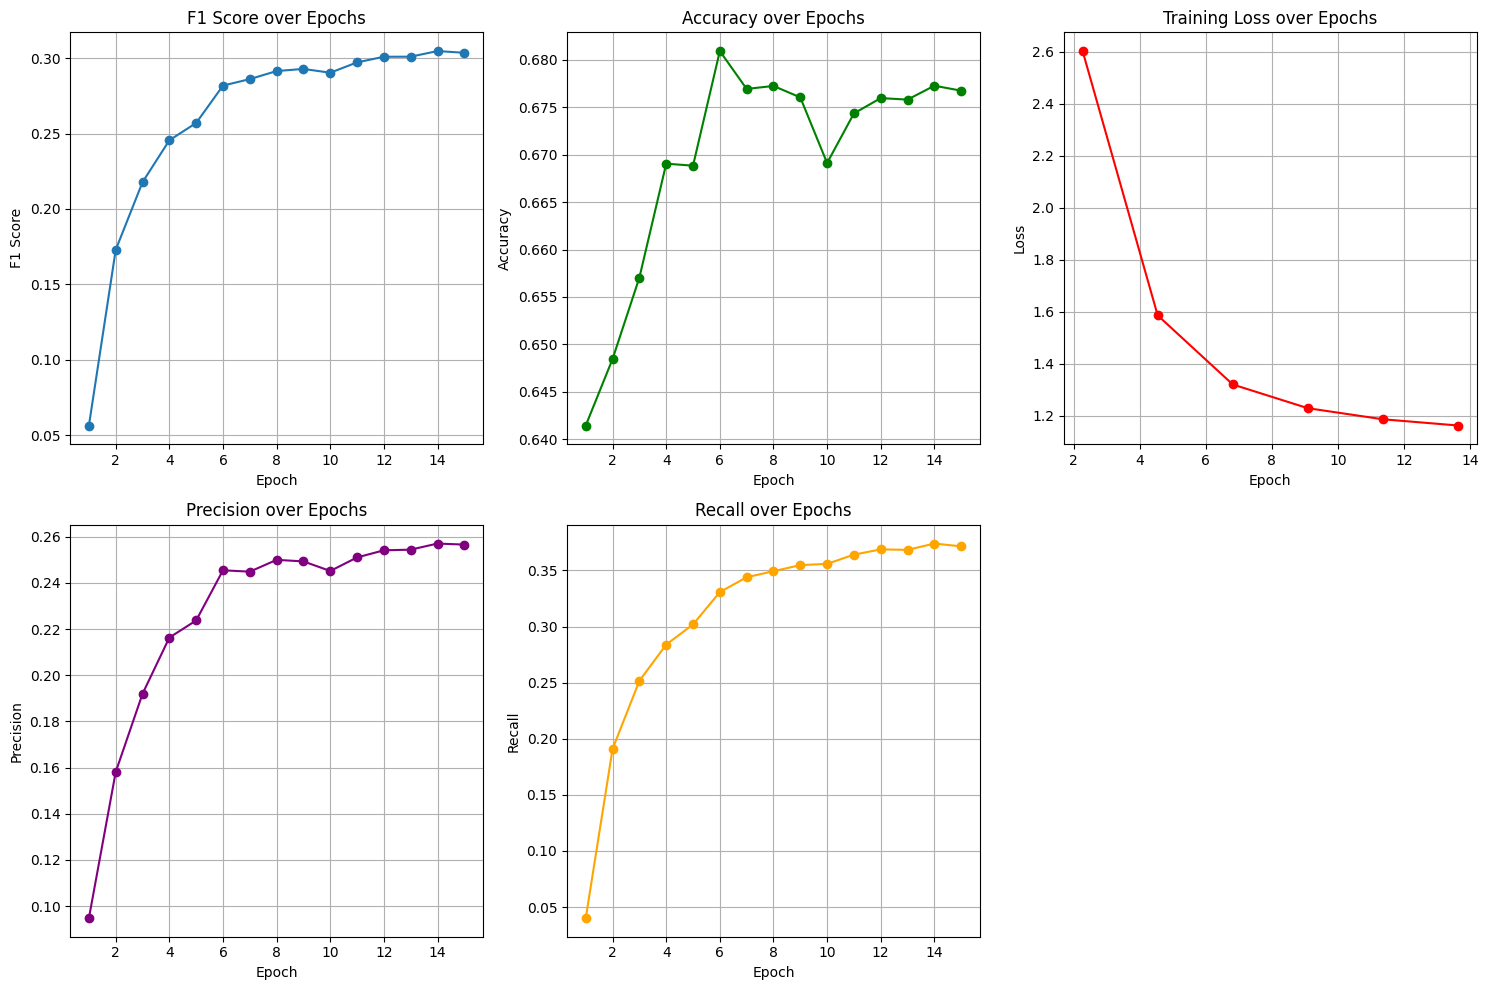

In [ ]:

import matplotlib.pyplot as plt
import pandas as pd

# Access the training history from the trainer object
history = trainer.state.log_history

# Filter out non-evaluation logs and extract relevant metrics
eval_history = [
    log for log in history if 'eval_loss' in log and 'epoch' in log
]

epochs = [log['epoch'] for log in eval_history]
eval_loss = [log['eval_loss'] for log in eval_history]
f1_scores = [log['eval_f1'] for log in eval_history]
accuracy_scores = [log['eval_accuracy'] for log in eval_history]
precision_scores = [log['eval_precision'] for log in eval_history]
recall_scores = [log['eval_recall'] for log in eval_history]


# Plotting
plt.figure(figsize=(15, 10))

# Plot F1 Score
plt.subplot(2, 3, 1)
plt.plot(epochs, f1_scores, marker='o')
plt.title('F1 Score over Epochs')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.grid(True)

# Plot Accuracy
plt.subplot(2, 3, 2)
plt.plot(epochs, accuracy_scores, marker='o', color='green')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

# Plot Training Loss
# We need to find the training loss entries, which are logged periodically, not just at the end of each epoch
train_loss_history = [log for log in history if 'loss' in log and 'epoch' in log]
train_epochs_loss = [log['epoch'] for log in train_loss_history]
train_losses = [log['loss'] for log in train_loss_history]


plt.subplot(2, 3, 3)
plt.plot(train_epochs_loss, train_losses, marker='o', color='red')
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

# Plot Precision
plt.subplot(2, 3, 4)
plt.plot(epochs, precision_scores, marker='o', color='purple')
plt.title('Precision over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.grid(True)

# Plot Recall
plt.subplot(2, 3, 5)
plt.plot(epochs, recall_scores, marker='o', color='orange')
plt.title('Recall over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.grid(True)


plt.tight_layout()
plt.show()

In [ ]:
from transformers import Trainer, TrainingArguments, AutoModelForTokenClassification

print("--- Starting Sanity Check: Overfitting on a small batch ---")

# --- You need to load the model object first ---
# (Assume 'label_list', 'id2label', 'label2id' are already defined)
model_name = "dmis-lab/biobert-base-cased-v1.2"
model = AutoModelForTokenClassification.from_pretrained(
    model_name,
    num_labels=len(LabelList),
    id2label=id2label,
    label2id=label2id
)

# 1. Create a tiny subset of your training data
tiny_train_dataset = tokenized_datasets["train"].select(range(8))

# 2. Use the standard, default Trainer for this test
# (No changes needed here)

# 3. Define Training Arguments for the test
sanity_check_args = TrainingArguments(
    output_dir="./sanity_check_results",
    per_device_train_batch_size=2,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=10,
    save_total_limit=2,
    learning_rate=2e-5,

    num_train_epochs=50,
    logging_strategy="epoch",
    report_to="none"
)

# 4. Initialize the Trainer with the tiny dataset
# NOTE: We use the default Trainer, not your custom WeightedLossTrainer
sanity_trainer = Trainer(
    model=model, # <-- Pass the loaded model object here, not the string
    args=sanity_check_args,
    train_dataset=tiny_train_dataset,
    eval_dataset=tiny_train_dataset, # Evaluate on the same tiny set
    data_collator=data_collator,      # You still need the data collator
    compute_metrics=compute_metrics # And the metrics function
)

# 5. Run the training
sanity_trainer.train()

# 6. Evaluate the final performance on the tiny set
final_metrics = sanity_trainer.evaluate()
print("\n--- Sanity Check Final Metrics ---")
print(final_metrics)

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline
from peft import PeftModel
import json # Import the json library

# --- 1. Define the paths and model names ---

# This is the original, full-sized model you started with
base_model_name = "dmis-lab/biobert-base-cased-v1.2"

# This is the path to the folder where you saved your LoRA adapters
adapter_path = "./final-biobert-ner-model"


# --- 2. Load the Base Model and Tokenizer ---
print(f"Loading base model: {base_model_name}...")
tokenizer = AutoTokenizer.from_pretrained(base_model_name)

# Load the base model in 4-bit for memory efficiency, just like in training
model = AutoModelForTokenClassification.from_pretrained(
    base_model_name, # Corrected: base_model_name should be the first argument
    num_labels=len(LabelList), # Your 23 custom labels
    id2label=id2label,
    label2id=label2id,
    quantization_config=None, # No quantization for simple inference, or define bnb_config if needed
    device_map="auto" # Automatically use GPU if available
)


# --- 3. Load and Merge the LoRA Adapters ---
print(f"Loading LoRA adapters from: {adapter_path}...")

# This command loads your saved adapter weights and merges them into the base model
model = PeftModel.from_pretrained(model, adapter_path)

# Optional: For faster inference, you can fully merge the adapters and unload the PEFT model
model = model.merge_and_unload()

print("✅ Model and adapters loaded and merged successfully!")


# --- 4. Run Inference ---
# Now you can use this final model in a pipeline as usual
ner_pipeline = pipeline(
    "ner",
    model=model,
    tokenizer=tokenizer,
    aggregation_strategy="simple"
)

# Example of a new, raw text document
new_raw_text = "A study of p53 and DCTN4 mutations in patients with cystic fibrosis showed promising results."

# Get the predictions
results = ner_pipeline(new_raw_text)

# Convert float32 to standard float for JSON serialization
def convert_floats(obj):
    # Check the type name as a string for robustness
    if type(obj).__name__ == 'float32':
        return float(obj)
    if isinstance(obj, dict):
        return {k: convert_floats(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [convert_floats(elem) for elem in obj]
    return obj

serializable_results = convert_floats(results)


# Print the results
print("\n--- Inference Results ---")
print(json.dumps(serializable_results, indent=2))

Loading base model: dmis-lab/biobert-base-cased-v1.2...


Some weights of BertForTokenClassification were not initialized from the model checkpoint at dmis-lab/biobert-base-cased-v1.2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use cuda:0
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Loading LoRA adapters from: ./final-biobert-ner-model...
✅ Model and adapters loaded and merged successfully!

--- Inference Results ---
[
  {
    "entity_group": "GENE_PROTEIN",
    "score": 0.47096434235572815,
    "word": "p",
    "start": 11,
    "end": 12
  },
  {
    "entity_group": "GENE_PROTEIN",
    "score": 0.2748274505138397,
    "word": "##53",
    "start": 12,
    "end": 14
  },
  {
    "entity_group": "GENE_PROTEIN",
    "score": 0.5947125554084778,
    "word": "dctn4",
    "start": 19,
    "end": 24
  },
  {
    "entity_group": "GENE_PROTEIN",
    "score": 0.2440495491027832,
    "word": "mutations",
    "start": 25,
    "end": 34
  },
  {
    "entity_group": "DISEASE",
    "score": 0.7151437401771545,
    "word": "cystic fibrosis",
    "start": 52,
    "end": 67
  },
  {
    "entity_group": "QUANTITY",
    "score": 0.2942196726799011,
    "word": "promising",
    "start": 75,
    "end": 84
  },
  {
    "entity_group": "QUANTITY",
    "score": 0.19943030178546906,
    "w

In [ ]:
import json
from transformers import pipeline
from peft import PeftModel
from transformers import AutoTokenizer, AutoModelForTokenClassification
import torch # Import torch to check for float32 type

# --- 1. Load the Final Model ---
base_model_name = "dmis-lab/biobert-base-cased-v1.2"
adapter_path = "./final-biobert-ner-model"
# (Make sure label_list, id2label, and label2id are defined)
base_model = AutoModelForTokenClassification.from_pretrained(
    base_model_name, num_labels=len(LabelList), id2label=id2label, label2id=label2id
)
tokenizer = AutoTokenizer.from_pretrained(base_model_name)
model = PeftModel.from_pretrained(base_model, adapter_path)
model = model.merge_and_unload()

# --- 2. Create and Use the Inference Pipeline ---
ner_pipeline = pipeline("ner", model=model, tokenizer=tokenizer, aggregation_strategy="simple")

# --- Helper function to convert float32 to float ---
def convert_floats(obj):
    # Check the type name as a string for robustness
    if type(obj).__name__ == 'float32':
        return float(obj)
    if isinstance(obj, dict):
        return {k: convert_floats(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [convert_floats(elem) for elem in obj]
    return obj


# --- 3. Process New Raw Documents ---
new_documents = [
    {"doc_id": "RAW_001", "text": "The patient was prescribed aspirin for chronic inflammation and reported myalgia."},
    {"doc_id": "RAW_002", "text": "Exome sequencing revealed a novel mutation in the CFTR gene, a known cause of cystic fibrosis."}
]
database_records = []
for doc in new_documents:
    entities = ner_pipeline(doc["text"])
    # Convert float32 to standard float before formatting and storing
    serializable_entities = convert_floats(entities)
    formatted_entities = [{"text": e['word'], "type": e['entity_group'], "score": round(e['score'], 4), "start": e['start'], "end": e['end']} for e in serializable_entities]
    database_records.append({"doc_id": doc['doc_id'], "original_text": doc['text'], "extracted_entities": formatted_entities})

# --- 4. Save the Static Database ---
with open("ner_database.json", 'w', encoding='utf-8') as f:
    json.dump(database_records, f, indent=2)
print("\n✅ Static database created successfully!")

Some weights of BertForTokenClassification were not initialized from the model checkpoint at dmis-lab/biobert-base-cased-v1.2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use cuda:0
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.



✅ Static database created successfully!
